**Made by LARBAOUI Yasmine Badr Elhouda**

in This Notebook , I implemented a **WaterMark** remover using a **U-net autoencoder** to remove watermarks from images

**Goal :** take watermakred image as input and reconstruct a clean version of the same image , keeping all important details intact

**How ?** Learning whih patterns belong to the original image and which belong to the watermark

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!gdown --id 17y1gkUhIV6rZJg1gMG-gzVMnH27fm4Ij


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17y1gkUhIV6rZJg1gMG-gzVMnH27fm4Ij
From (redirected): https://drive.google.com/uc?id=17y1gkUhIV6rZJg1gMG-gzVMnH27fm4Ij&confirm=t&uuid=fe8221d8-cd44-4545-a956-4088b3ebb091
To: /content/CLWD.rar
100% 3.35G/3.35G [00:37<00:00, 88.5MB/s]


In [4]:
!apt-get install -y unrar
!unrar x /content/CLWD.rar /content/dataset_extracted/


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59683.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59684.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59685.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59686.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59687.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59688.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59689.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/5969.jpg      97%  OK 
Extracting  /content/dataset_extracted/CLWD/train/Watermark_free_image/59690.jpg      9

In [5]:

import os
import numpy as np # arrays and numerical computations
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# compare quality of reconstructed images with the original ones
from skimage.metrics import peak_signal_noise_ratio as psnr
# compare perceptual similarity between images
from skimage.metrics import structural_similarity as ssim


##**Data Loading and Processing**

###**Loading Images**

\- Images are loaded from disk using a fast TensorFlow-based function (load_image_fast).

\- Each image is resized to 128×128 pixels to standardize input size.

\- Pixel values are normalized to the range [0,1] by dividing by 255.

    Neural networks work better when inputs are standardized and normalized. Different image sizes or pixel ranges can slow training or produce unstable results.

In [6]:
def load_image_fast(path, image_size=(128,128)):
    img = tf.io.read_file(path)
    # 3-channel RGB image tensor
    img = tf.image.decode_jpeg(img, channels=3)
    # resize images
    img = tf.image.resize(img, image_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img

###**Organizing Image pairs**

Each watermarked image has a corresponding watermark-free target image.

    The model learns a mapping from a watermarked image to its clean version, so keeping images correctly paired is essential.

In [7]:
dataset_root = "./dataset_extracted/CLWD"   # dossier du dataset dans le même dossier que le notebook
image_size = (128,128) # target size for all images
batch_size = 16

def get_image_pairs_tf(subset="train"):
    # construct paths for input (Watermarked) and target (clean) images
    input_folder  = os.path.join(dataset_root, subset, "Watermarked_image")
    target_folder = os.path.join(dataset_root, subset, "Watermark_free_image")

    #list and sort all image file paths to ensure correct input-target alignment
    input_files  = sorted([os.path.join(input_folder, f) for f in os.listdir(input_folder)])
    target_files = sorted([os.path.join(target_folder, f) for f in os.listdir(target_folder)])

    # Return two lists:  inputs (watermarked) and one for targets (clean)
    return input_files, target_files


In [8]:
# Load training and testing image file paths
train_inputs, train_targets = get_image_pairs_tf("train")
test_inputs, test_targets   = get_image_pairs_tf("test")

# Print dataset size
print(f"Nombre d'images train: {len(train_inputs)}, test: {len(test_inputs)}")

Nombre d'images train: 60000, test: 10000


###**Creating TensorFlow Dataset**

\- File paths are converted into TensorFlow datasets.

\- The dataset is shuffled (randomized) to improve **training generalization**.

\- Each image is loaded and preprocessed on-the-fly for efficiency (map + AUTOTUNE).

\- Data is batched (batch_size=16) and prefetched to speed up training.

    batching and prefetching:
    Neural networks process data in batches for computational efficiency.
    Prefetching overlaps data loading with model training, reducing idle time.

In [9]:
## Function to create a TensorFlow dataset from lists of input and target image file paths

def create_tf_dataset_fast(inputs, targets, batch_size=16, shuffle=True):

    # Convert Python lists of file paths to TensorFlow constants (for tf.data)
    inputs  = tf.constant(inputs)
    targets = tf.constant(targets)

    # Create a dataset where each element is a tuple (input_path, target_path)
    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    # if we want the dataset to randomize training samples
    if shuffle:
        dataset = dataset.shuffle(buffer_size=2000)

    # Load + preprocessing for images
    # parallel mapping for time optimization
    dataset = dataset.map(
        lambda x, y: (load_image_fast(x), load_image_fast(y)),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Group images into batches for training
    dataset = dataset.batch(batch_size)
    # prefetch batching
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [10]:
def show_images_tf(images, titles=None):
    import matplotlib.pyplot as plt
    import numpy as np

    images = np.array(images)
    images = images.astype(np.float32)
    images = np.clip(images, 0, 1)

    n = len(images)
    plt.figure(figsize=(3*n,3))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(images[i])
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()


In [11]:
# Create the training dataset from file paths (Shuffle = yes for training )
train_dataset = create_tf_dataset_fast(train_inputs, train_targets, batch_size=16)

# Create the testing dataset from file paths
test_dataset  = create_tf_dataset_fast(test_inputs, test_targets, batch_size=16, shuffle=False)

###**Visualizing the first 5 input and target images from the initial batch of the training dataset.**

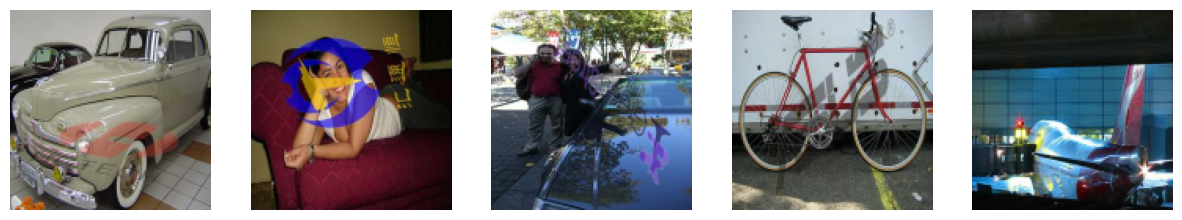

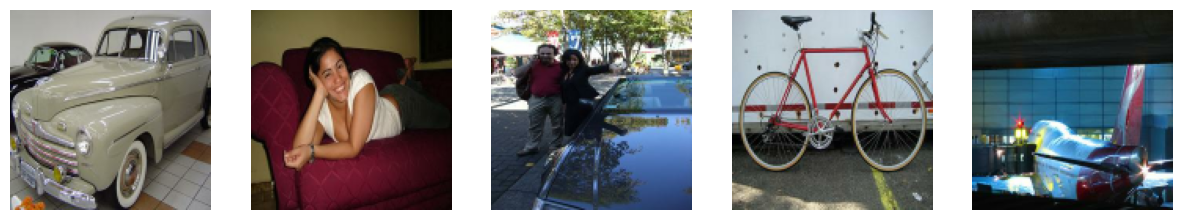

In [12]:
for x_batch, y_batch in train_dataset.take(1): #     # Retrieve the first batch of input and target images
    # Visualizing the first 5 input/target images from the batch
    show_images_tf(x_batch[:5])
    show_images_tf(y_batch[:5])


###**Mixed Precision Training**

\- Mixed precision allows using both float16 and float32 for computations.

\- This speeds up training and reduces GPU memory usage without sacrificing model accuracy.

    Modern GPUs handle float16 faster than float32. Using mixed precision improves performance on large datasets.

In [13]:
# for accelerating the trainig
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

###**Building the Autoencoder Model**

####**1. Encoder : compression & features extraction**

\- The encoder progressively reduces the size of the input image while increasing the number of feature channels.

\- Each convolution layer detects patterns in the image, such as edges, textures, and shapes.

\- Max pooling reduces the spatial size of the image, keeping only the most important information.

\- Batch normalization is used to stabilize training and make learning faster.

    The encoder learns a compact representation of the image, highlighting both watermarks and real image details.

####**2. Bottleneck : most compressed representation**

\- The bottleneck is the deepest layer of the network where the image is highly compressed.

\- It contains the most abstract features learned from the input image.

    It allows the model to understand the difference between watermarks and real content by focusing on high-level patterns.

####**3. decoder : reconstruction**

\- The decoder gradually upsamples the compressed features to reconstruct an image of the original size.

\- Convolution layers refine the upsampled features to produce a clear image.

    The decoder transforms the learned features back into an image without watermarks.

####**4. Skipconnection**


\- Skip connections  links between encoder layers and corresponding decoder layers.

\- pass high-resolution information directly from the encoder to the decoder.

    This helps the decoder reconstruct fine details that would otherwise be lost during compression.

####**5. Activation functions**

\- ReLU is used in most layers to allow the model to learn complex, non-linear patterns.

\- Sigmoid in the output layer ensures pixel values are between 0 and 1, which is standard for images.

In [14]:
def build_unet(image_size=(128,128,3)):     # Define a U-Net autoencoder

    inputs = layers.Input(shape=image_size)

    # -------- Encoder : compress the image to learn features  --------
    # initial conv layer to capture lo-level features : basic patterns (edges , corners)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1) # normalize to make learning faster and more stable
    p1 = layers.MaxPooling2D()(c1) # reduce the image size by 2* to focus on important features

    # repeat : extract more complex features and reduce dize
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D()(c3)
    # ----- encoder finished : we have a compressed representation of the image

    # -------- capture high level features  : most important information of the image --------
    b = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)

    # -------- Decoder : reconstruct the clean image --------
    u3 = layers.UpSampling2D()(b) # increase the image size by 2
    u3 = layers.Concatenate()([u3, c3]) # add details from encoder -  the skip connection
    # refine the features after merging
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u3)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    # Final layer creates the output image with 3 color channels RGB
    # Sigmoid makes the pixel values between 0 and 1
    outputs = layers.Conv2D(3, 1, activation='sigmoid')(c6)

    return models.Model(inputs, outputs)


####**LOSS Function**

Combines **pixel-wise difference (L1 loss)** and **structural similarity (SSIM loss)** : encourage the network to produce images that are both numerically accurate and visually realistic.
    


In [15]:
def combined_loss(y_true, y_pred):
    # L1 measures pixel-by-pixel difference beteen the true and predicted images
    l1 = tf.reduce_mean(tf.abs(y_true - y_pred))

    # calculate SSIM loss structural similarity Index
    # SSIM compares images based on perceived visuali quality
    # so lower values mean better similarity
    ssim_loss = 1 - tf.reduce_mean(
        tf.image.ssim(y_true, y_pred, max_val=1.0)
    )

    # Combine losses with stronger weight on pixel correction
    # more importance to L1 (accurate pixel reconstruction)
    # SSIM ensures the output also looks visually similar
    return 3.0 * l1 + 0.3 * ssim_loss


In [16]:
model = build_unet()

model.compile(

    # Adam optimizer : adapts learning rates for each parameter
    # learning rate = 0.0003 for stable and efficient trainig
    # (adjusted after lot of essays based on the results of tests)
    optimizer=optimizers.Adam(learning_rate=3e-4),

    loss=combined_loss
)


###**Training the Model**

In [17]:
callbacks = [
    # reduce the learning rate if the validation loss does not improve for 5 epochs
    # factor = 0.5 : the learning rate will be halved each time this happens
    # so themodel converge ore efficiently and avoid getting stuck
    tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
]

num_epochs = 20 # trainig cycles

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=num_epochs,
    callbacks=callbacks
)

Epoch 1/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 202s 45ms/step - loss: 0.1401 - val_loss: 0.0934 - learning_rate: 3.0000e-04
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 163s 43ms/step - loss: 0.1013 - val_loss: 0.0835 - learning_rate: 3.0000e-04
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 164s 44ms/step - loss: 0.0877 - val_loss: 0.0838 - learning_rate: 3.0000e-04
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 173s 46ms/step - loss: 0.0771 - val_loss: 0.1076 - learning_rate: 3.0000e-04
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 202s 46ms/step - loss: 0.0708 - val_loss: 0.0632 - learning_rate: 3.0000e-04
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 163s 43ms/step - loss: 0.0637 - val_loss: 0.0683 - learning_rate: 3.0000e-04
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 203s 44ms/step - loss: 0.0604 - val_loss: 0.0655 - learning_rate: 3.0000e-04
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 202s 44ms/step - loss: 0.0575 - val_loss: 0.0631 - learning_rate: 3.0000e-04
Epoch 9/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 163s 4

####**Visualing the trainig loss vs validation loss**


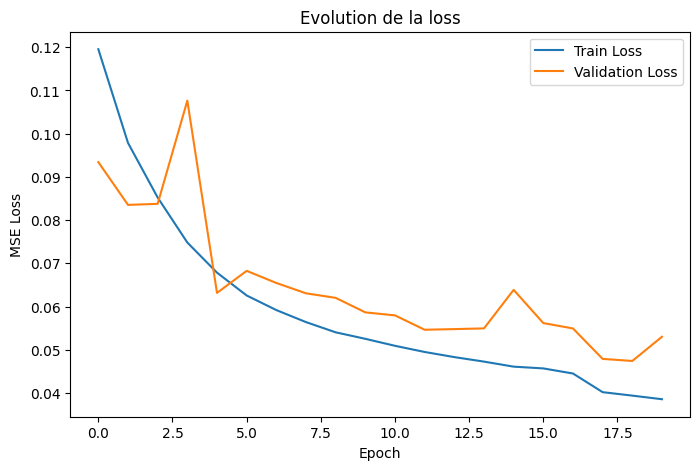

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Evolution de la loss")
plt.legend()
plt.show()

####**Interpretation**

Training convergence : The training loss decreases steadily from 0.14 to ~0.039 over 20 epochs.

    model learns effectively and optimization is stable.

Validation Loss :    

\- The validation loss shows an overall decreasing trend throughout training.

\- This indicates that the model’s performance on unseen data improves over time.

\- The validation loss stays close to the training loss -> the model does not overfit.


###**Testing and visualization of the Predictions**

\- take a batch from the test dataset to evaluate the model

\- predict watermark-free images using the trained model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step


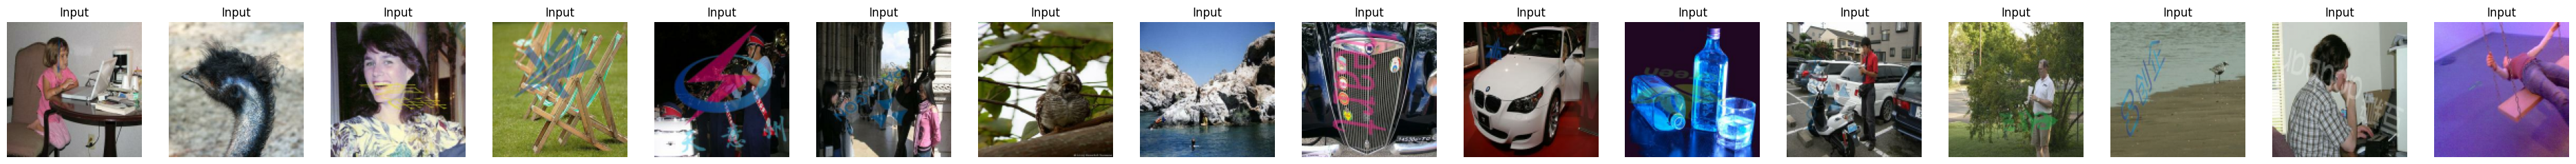

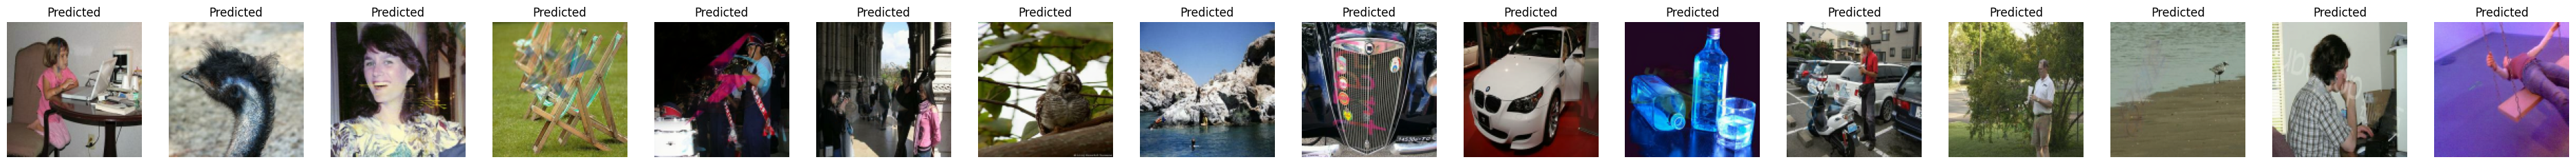

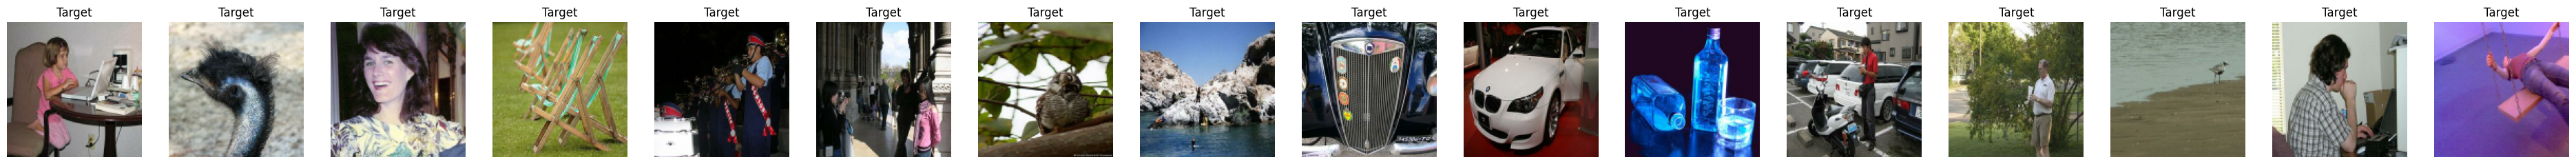

In [19]:
# Prendre un batch du test
for x_batch, y_batch in test_dataset.take(1):
    y_pred = model.predict(x_batch)

show_images_tf(x_batch.numpy(), titles=["Input"]*x_batch.shape[0])
show_images_tf(y_pred, titles=["Predicted"]*x_batch.shape[0])
show_images_tf(y_batch.numpy(), titles=["Target"]*y_batch.shape[0])


Some of the correct Result from the model application result

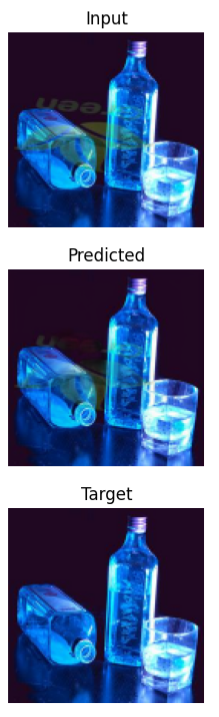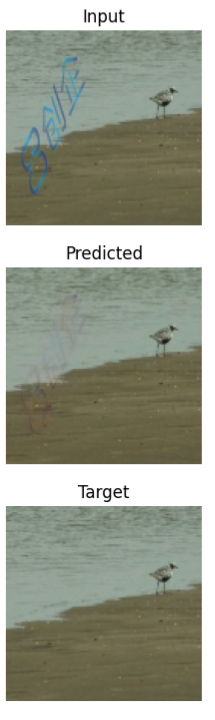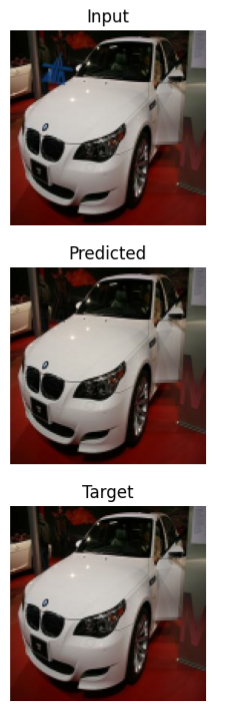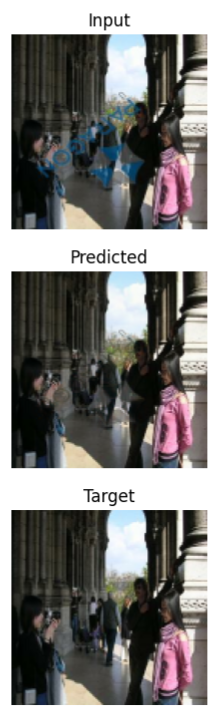

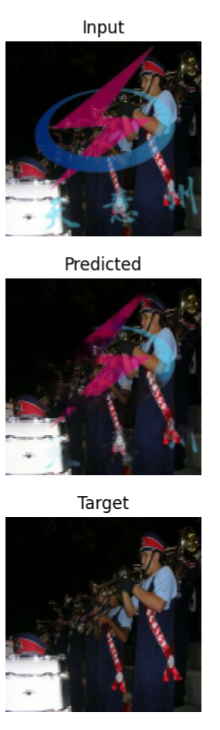

In [21]:
model.save("watermark_remover_model.keras")
